<a href="https://colab.research.google.com/github/Knchna/Fake-News-Prediction/blob/main/Kanchana_Exit_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1:** Text Exploration

## Import Libraries

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string                                 # for punctuation removal, and lowercase conversion

# For NLP
import nltk
nltk.download('punkt_tab')                    # for tokenization
from nltk.corpus import stopwords             # for stopwords
from nltk.stem import PorterStemmer           # for stemming
nltk.download('wordnet')                      # for lemmataization
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer     # for BoW

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer     # for tf-idf

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Dataset

In [ ]:
filepath = "/content/drive/MyDrive/ICT_AIML Class/Datasets/Fake_real/"

# Extracting the 2 files seperately into separate dfs
df_true = pd.read_csv(filepath + "True.csv")
df_fake = pd.read_csv(filepath + "Fake.csv")

print(df_true.shape)
print(df_fake.shape)

(21417, 4)
(23481, 4)


In [ ]:
# Add a label column named 'Class' to each DataFrame.
df_true['Class'] = 0      # 0 for true news
df_fake['Class'] = 1      # 1 for fake news

df_fake.head()
df_true.head()

,title,text,subject,date,Class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [ ]:
# Concatenate the two DataFrames
df_news = pd.concat([df_true, df_fake], ignore_index=True)

print("\nCombined DataFrame shape:", df_news.shape)


Combined DataFrame shape: (44898, 5)


In [ ]:
# Head
df_news.head()

,title,text,subject,date,Class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


## EDA

In [ ]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   Class    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
# relevant input data is present only in columns 'title' and 'text'

# Combine 'title' and 'text' into a new 'content' column with blank space separation
df_news['content'] = df_news['title'] + ' ' + df_news['text']

df_news.head()

,title,text,subject,date,Class,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0,Trump wants Postal Service to charge 'much mor...


In [ ]:
# Drop the original 'title', 'text', 'subject', and 'date' columns. Retain target column 'Class'
df_news = df_news.drop(columns=['title', 'text', 'subject', 'date'])

print("DataFrame after combining and dropping columns:")
df_news.head()

DataFrame after combining and dropping columns:


,Class,content
0,0,"As U.S. budget fight looms, Republicans flip t..."
1,0,U.S. military to accept transgender recruits o...
2,0,Senior U.S. Republican senator: 'Let Mr. Muell...
3,0,FBI Russia probe helped by Australian diplomat...
4,0,Trump wants Postal Service to charge 'much mor...


In [ ]:
print(df_news.shape)

(44898, 2)


In [ ]:
target_col = 'Class'

### Missing Value Checking

In [ ]:
# Check for missing values
df_news.isnull().sum()

,0
Class,0
content,0


In [ ]:
# Inference:
  # No missing values in the dataset

### Duplicates Checking

In [ ]:
# Check for duplicate values
df_news.duplicated().sum()

np.int64(5793)

In [ ]:
df_news = df_news.drop_duplicates()

# After dropping duplicate rows
df_news.shape

(39105, 2)

### Checking Class Imbalance

In [ ]:
# Checking class imbalance
df_news['Class'].value_counts()

,count
Class,
0,21197
1,17908


In [ ]:
df_news.shape[0]

39105

In [ ]:
print(f"Percentage of True News: {((df_news['Class'].value_counts()[0]) / df_news.shape[0]) * 100}")
print(f"Percentage of Fake News: {((df_news['Class'].value_counts()[1]) / df_news.shape[0]) * 100}")

Percentage of True News: 54.20534458509142
Percentage of Fake News: 45.79465541490858


In [ ]:
# The dataset is mostly balanced

### Article Length, Vocab Size & Word Frequency

### Clean and preprocess the text

In [ ]:
# Initialize NLTK
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return processed_tokens

# Apply preprocessing to create a new column of cleaned tokens list
df_news['preprocessed_content'] = df_news['content'].apply(preprocess_text)
display(df_news.head())

,Class,content,preprocessed_content
0,0,"As U.S. budget fight looms, Republicans flip t...","[u, budget, fight, loom, republican, flip, fis..."
1,0,U.S. military to accept transgender recruits o...,"[u, military, accept, transgender, recruit, mo..."
2,0,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, u, republican, senator, let, mr, muel..."
3,0,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, australian, diplo..."
4,0,Trump wants Postal Service to charge 'much mor...,"[trump, want, postal, service, charge, much, a..."


#### Article Length Analysis

Article Length Statistics:


,article_length
count,39105.000000
mean,233.781332
std,178.159052
min,2.000000
25%,128.000000
50%,213.000000
75%,293.000000
max,4850.000000


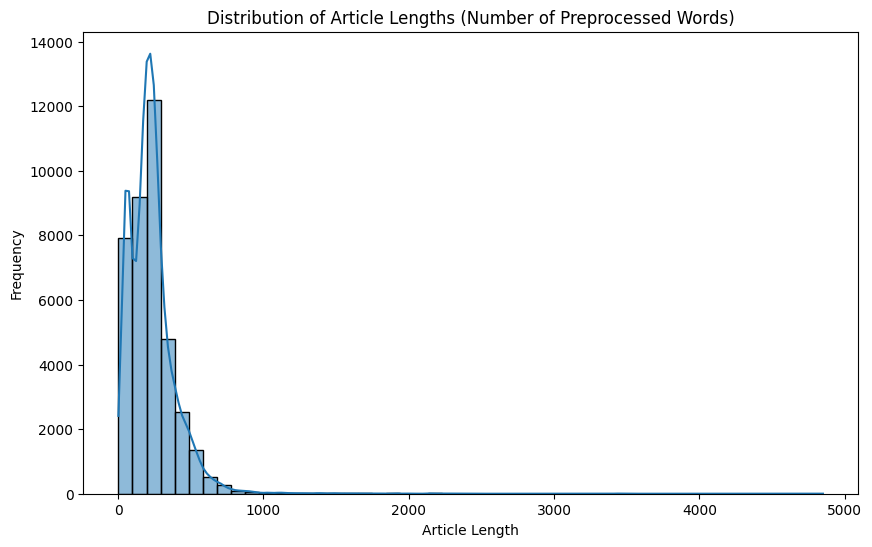

In [ ]:
# Calculate article length (number of words) after preprocessing
df_news['article_length'] = df_news['preprocessed_content'].apply(len)

# Display basic statistics and a histogram of article lengths
print("Article Length Statistics:")
display(df_news['article_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_news['article_length'], bins=50, kde=True)
plt.title('Distribution of Article Lengths (Number of Preprocessed Words)')
plt.xlabel('Article Length')
plt.ylabel('Frequency')
plt.show()

#### Vocabulary Size

In [ ]:
from collections import Counter

# Flatten the list of all processed words to get the entire corpus
all_words = [word for sublist_of_words in df_news['preprocessed_content'] for word in sublist_of_words]

# Calculate vocabulary size
vocabulary_size = len(set(all_words))
print(f"Total Vocabulary Size: {vocabulary_size}")

Total Vocabulary Size: 206043


#### Word Frequency Analysis


20 Most Common Words:


[('trump', 130577),
 ('said', 120893),
 ('u', 59938),
 ('state', 53078),
 ('would', 49737),
 ('president', 47624),
 ('republican', 37793),
 ('people', 36377),
 ('one', 31750),
 ('year', 30643),
 ('reuters', 28390),
 ('new', 28363),
 ('also', 27061),
 ('house', 26737),
 ('donald', 26064),
 ('government', 25846),
 ('say', 25490),
 ('obama', 24065),
 ('clinton', 24029),
 ('time', 22979)]

/tmp/ipykernel_4945/2004789795.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='viridis')


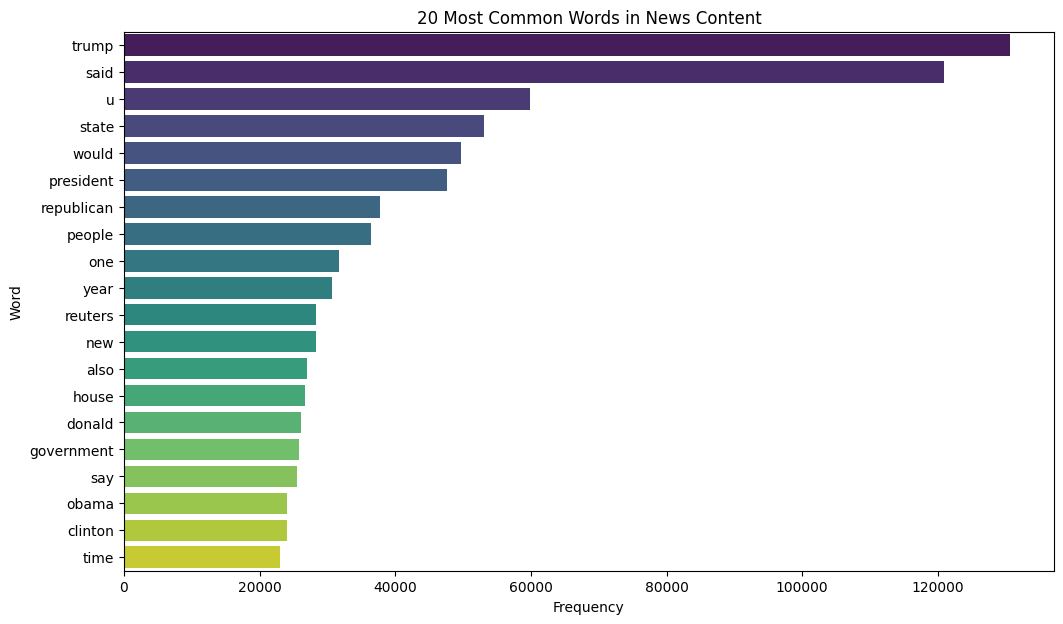

In [ ]:
# Get word frequencies
word_freq = Counter(all_words)

# Display the 20 most common words
print("\n20 Most Common Words:")
display(word_freq.most_common(20))

# Plotting the most common words
common_words_df = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='viridis')
plt.title('20 Most Common Words in News Content')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# Analytical Question Answers:

1.   Fake articles could be shorter in length than True articles
2. Noise such as punctuation, spelling errors, numbers, irrelevant words, and inconsistent formatting can create less meaningful features and reduce model performance.  
3. If one class is much larger, the model may become biased toward that class. Then it won't oredict properly

# **Task 2:** NLP Preprocessing

In [ ]:
# Join the processed tokens back into a single string for each document
df_news['cleaned_text_string'] = df_news['preprocessed_content'].apply(lambda x: ' '.join(x))

In [ ]:
df_news.head()

,Class,content,preprocessed_content,article_length,cleaned_text_string
0,0,"As U.S. budget fight looms, Republicans flip t...","[u, budget, fight, loom, republican, flip, fis...",444,u budget fight loom republican flip fiscal scr...
1,0,U.S. military to accept transgender recruits o...,"[u, military, accept, transgender, recruit, mo...",379,u military accept transgender recruit monday p...
2,0,Senior U.S. Republican senator: 'Let Mr. Muell...,"[senior, u, republican, senator, let, mr, muel...",269,senior u republican senator let mr mueller job...
3,0,FBI Russia probe helped by Australian diplomat...,"[fbi, russia, probe, helped, australian, diplo...",235,fbi russia probe helped australian diplomat ti...
4,0,Trump wants Postal Service to charge 'much mor...,"[trump, want, postal, service, charge, much, a...",494,trump want postal service charge much amazon s...


In [ ]:
# Displaying only necessary columns
display(df_news[['content', 'cleaned_text_string', 'Class']].head())

,content,cleaned_text_string,Class
0,"As U.S. budget fight looms, Republicans flip t...",u budget fight loom republican flip fiscal scr...,0
1,U.S. military to accept transgender recruits o...,u military accept transgender recruit monday p...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,senior u republican senator let mr mueller job...,0
3,FBI Russia probe helped by Australian diplomat...,fbi russia probe helped australian diplomat ti...,0
4,Trump wants Postal Service to charge 'much mor...,trump want postal service charge much amazon s...,0


## Train-Test-Split

In [ ]:
# Train Test Split

X_bow = df_news['cleaned_text_string']
y = df_news[target_col]

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y,test_size=0.2,random_state = 42,)

In [ ]:
# Verifying
print(X_train_bow.shape)
print(y_train.shape)
print(X_test_bow.shape)
print(y_test.shape)

(31284,)
(31284,)
(7821,)
(7821,)


## Bag-of-Words (BoW) Representation [Count Vectorization]

In [ ]:
# obj
count_vec_obj = CountVectorizer(max_features=5000) # Limiting to top 5000 words

# applying using fit_transform() on training data
X_train_bow = count_vec_obj.fit_transform(X_train_bow)

# only transform() on test data
X_test_bow = count_vec_obj.transform(X_test_bow)

In [ ]:
print("Sample of BoW feature names (first 20):")
display(count_vec_obj.get_feature_names_out()[:20])

Sample of BoW feature names (first 20):


array(['abadi', 'abandon', 'abandoned', 'abbas', 'abc', 'abdullah', 'abe',
       'abedin', 'ability', 'able', 'abortion', 'abroad', 'absence',
       'absolute', 'absolutely', 'absurd', 'abu', 'abuse', 'abused',
       'academic'], dtype=object)

In [ ]:
print(X_train_bow.shape)
print(X_test_bow.shape)

(31284, 5000)
(7821, 5000)


## TrainTestSplit for TF-IDF

In [ ]:
X_tfidf = df_news['cleaned_text_string']
y = df_news[target_col]

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y,test_size=0.2,random_state=42,)

In [ ]:
# Verifying the train test split
print(X_train_tfidf.shape)
print(y_train.shape)
print(X_test_tfidf.shape)
print(y_test.shape)

(31284,)
(31284,)
(7821,)
(7821,)


In [ ]:
# before tf-idf
X_train_tfidf.head()

,cleaned_text_string
4997,highlight trump presidency march pm est reuter...
21569,trump literally sabotaging case nyc terrorist ...
43503,north korea trump recklessness could trigger a...
15110,tpp nation agree core element deal final state...
16670,unlikely ally eye vote legalize cannabis new z...


In [ ]:
# Create TF-IDF object
tfidf = TfidfVectorizer(max_features=7000)

# Convert text into TF-IDF features

X_train_tfidf = tfidf.fit_transform(X_train_tfidf)
X_test_tfidf = tfidf.transform(X_test_tfidf)

In [ ]:
# After TF-IDF transformation we get a sparse matrix
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4244427 stored elements and shape (31284, 7000)>

# Analytical Question Answers:

1. Data cleaning and stopword removal    
2. Stopwords can sometimes carry meaning, especially words like “not”. Removing them can reduce noise but may also remove information important for sentiment or meaning.    
3. No. Stemming simply cuts words down to root form, while lemmatization produces a meaningful base word.

# **Task 3:** Machine Learning Model Development

## Logistic Regression

In [ ]:
# creating object
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# train the model
log_reg .fit(X_train_tfidf, y_train)

# make predictions on X_test
y_pred_log_reg = log_reg.predict(X_test_tfidf)

## Support Vector Machine (SVC)

In [ ]:
# object
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# make predictions on X_test
y_pred_svm = svm_model.predict(X_test_tfidf)

## Random Forest

In [ ]:
# object
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train_tfidf, y_train)

# make predictions on X_test
y_pred_rf = rf_model.predict(X_test_tfidf)

# Analytical Question Answers:

1. If the classes are imbalanced, a model can get high accuracy by mostly predicting the majority class. thus misleading.
2. Linear SVM. Because of the hyperparameters and vector decision boundaries
3. Recall

# **Task 4:** Error Analysis and Model Implementation

In [ ]:
# evaluate the Log Reg model by comparing with y_test
print("Evaluating Logistic Regression Model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_log_reg))
print("Precision :", precision_score(y_test, y_pred_log_reg))
print("Recall :", recall_score(y_test, y_pred_log_reg))
print("F1 Score :", f1_score(y_test, y_pred_log_reg))
print("ROC-AUC :", roc_auc_score(y_test, y_pred_log_reg))

clsf_log_reg = classification_report(y_test,y_pred_log_reg)
print("\nClassification Report :")
print(clsf_log_reg)

conf_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix :")
print(conf_log_reg)

Evaluating Logistic Regression Model:

Accuracy : 0.9849124152921621
Precision : 0.988933030646992
Recall : 0.9778338945005611
F1 Score : 0.983352144469526
ROC-AUC : 0.9843362566230783

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4257
           1       0.99      0.98      0.98      3564

    accuracy                           0.98      7821
   macro avg       0.99      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821


Confusion Matrix :
[[4218   39]
 [  79 3485]]


In [ ]:
# Evaluation OF svm
print("Evaluating SVM Model:")
print("\nAccuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC Score :", roc_auc_score(y_test, y_pred_svm))

# Confusion Matrix
conf_svm_model = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
print(conf_svm_model)

# Classification Report
clsf_svm_model = classification_report(y_test,y_pred_svm)
print("\nClassification Report:")
print(clsf_svm_model)

Evaluating SVM Model:

Accuracy : 0.9925840685334356
Precision : 0.9940811724915445
Recall : 0.9896184062850729
F1 Score : 0.9918447694038245
ROC-AUC Score : 0.9923426774201967

Confusion Matrix:
[[4236   21]
 [  37 3527]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4257
           1       0.99      0.99      0.99      3564

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [ ]:
# Evaluation OF Random fOREST
print("Evaluating Random Forest Model:")
print("\nAccuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC Score :", roc_auc_score(y_test, y_pred_rf))

# Confusion Matrix
conf_rf_model = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(conf_rf_model)

# Classification Report
clsf_rf_model = classification_report(y_test,y_pred_rf)
print("\nClassification Report:")
print(clsf_rf_model)

Evaluating Random Forest Model:

Accuracy : 0.9826109193197801
Precision : 0.9922458357265939
Recall : 0.9694163860830527
F1 Score : 0.9806982685211467
ROC-AUC Score : 0.9815369456842326

Confusion Matrix:
[[4230   27]
 [ 109 3455]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4257
           1       0.99      0.97      0.98      3564

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



In [ ]:
# Compare all three models

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Linear SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log_reg),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC Score': [
        roc_auc_score(y_test, y_pred_log_reg),
        roc_auc_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_pred_rf)
    ]
})

display(model_comparison.sort_values('F1 Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
1,Linear SVM,0.992584,0.994081,0.989618,0.991845,0.992343
0,Logistic Regression,0.984912,0.988933,0.977834,0.983352,0.984336
2,Random Forest,0.982611,0.992246,0.969416,0.980698,0.981537


### Error Analysis: Misclassified Samples (Logistic Regression)

In [ ]:
X_tfidf = df_news['cleaned_text_string']
y = df_news[target_col]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(max_features=7000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [ ]:
# Create a DataFrame to analyze misclassifications
error_df = pd.DataFrame({
    'True_Class': y_test,
    'Predicted_Class': y_pred_log_reg,
    'Text_Content': X_test_text
})

# Filter for misclassified samples
misclassified_samples = error_df[error_df['True_Class'] != error_df['Predicted_Class']]

print(f"Total Misclassified Samples: {len(misclassified_samples)}")
print("\nFirst 15 Misclassified Samples (Logistic Regression):")
display(misclassified_samples.head(15))

Total Misclassified Samples: 118

First 15 Misclassified Samples (Logistic Regression):


,True_Class,Predicted_Class,Text_Content
14907,0,1,google broadens takedown extremist youtube vid...
2319,0,1,instant view reaction grand jury subpoena rega...
9148,0,1,trump cnn fault muslim community reporting peo...
9004,0,1,democrat gun control sitin spark social medium...
35808,1,0,super tuesday projection map real clear politi...
38638,1,0,grexit greek vote austerity return rescue loan...
43349,1,0,palestinian protester attack u embassy lebanon...
13764,0,1,reaction prince harrys engagement meghan markl...
8131,0,1,u house panel slam former nsa contractor snowd...
36121,1,0,breaking iran publicly humiliates obama…unveil...


### Identifying Influential Words/Features (Logistic Regression Coefficients)

In [ ]:
# Get feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get coefficients from the Logistic Regression model
# log_reg.coef_[0] because it's a binary classification model (one coefficient array)
coefficients = log_reg.coef_[0]

# Create a DataFrame of feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by coefficient to find most influential words for each class
feature_importance_sorted = feature_importance.sort_values(by='Coefficient', ascending=False)

print("Top 20 words indicative of 'Fake' news (Class 1 - positive coefficients):")
display(feature_importance_sorted.head(20))

print("\nTop 20 words indicative of 'True' news (Class 0 - negative coefficients):")
display(feature_importance_sorted.tail(20).sort_values(by='Coefficient', ascending=True))

Top 20 words indicative of 'Fake' news (Class 1 - positive coefficients):


,Feature,Coefficient
6701,video,9.216119
3061,image,9.022633
6691,via,8.909031
2700,gop,5.925591
2919,hillary,5.226684
2203,even,4.922635
4066,mr,4.689434
3646,like,4.197226
6888,wire,4.067835
251,america,3.956790



Top 20 words indicative of 'True' news (Class 0 - negative coefficients):


,Feature,Coefficient
5306,reuters,-21.837249
5448,said,-18.733548
6792,washington,-6.592488
6487,tuesday,-5.162931
6823,wednesday,-5.129945
6334,thursday,-4.665633
2576,friday,-4.485375
4022,monday,-4.109699
4230,nov,-3.682786
4767,presidential,-3.565439


### Visualization of Most Influential Words

/tmp/ipykernel_4945/2715015367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_sorted.head(20), palette='Reds_r')


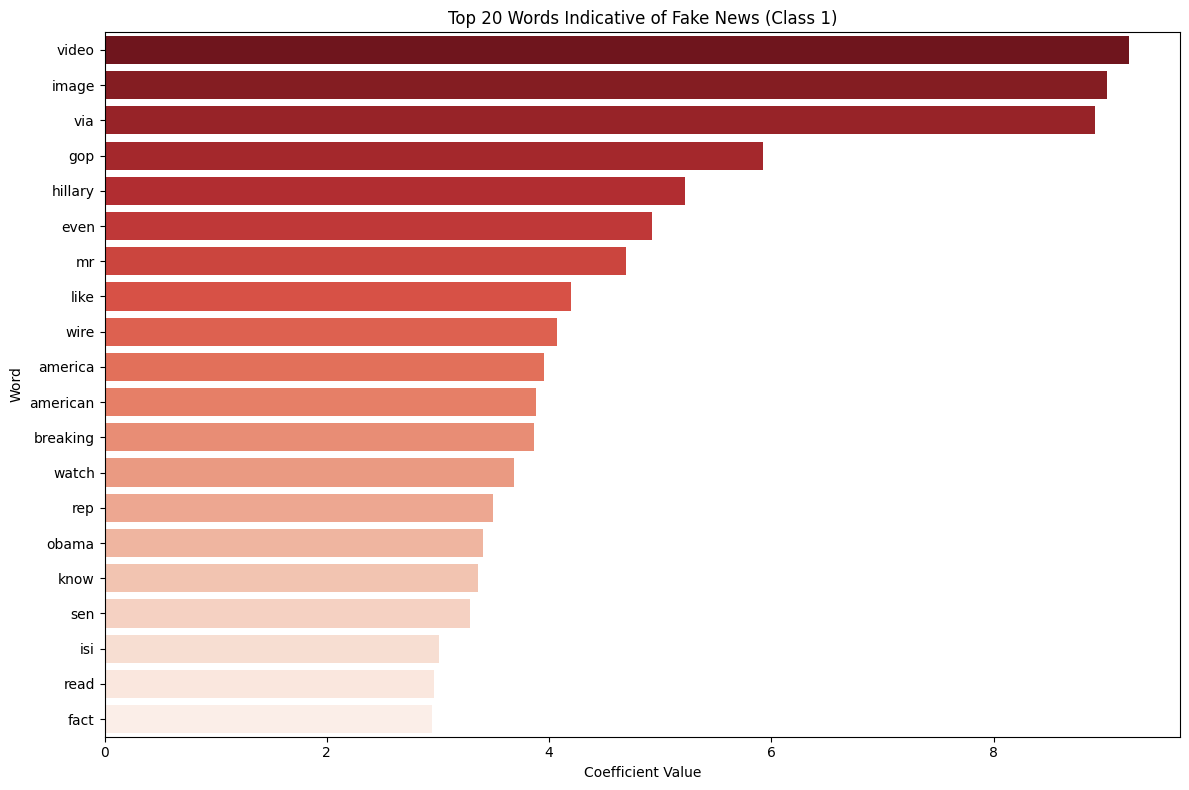

/tmp/ipykernel_4945/2715015367.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_sorted.tail(20).sort_values(by='Coefficient', ascending=True), palette='Blues')


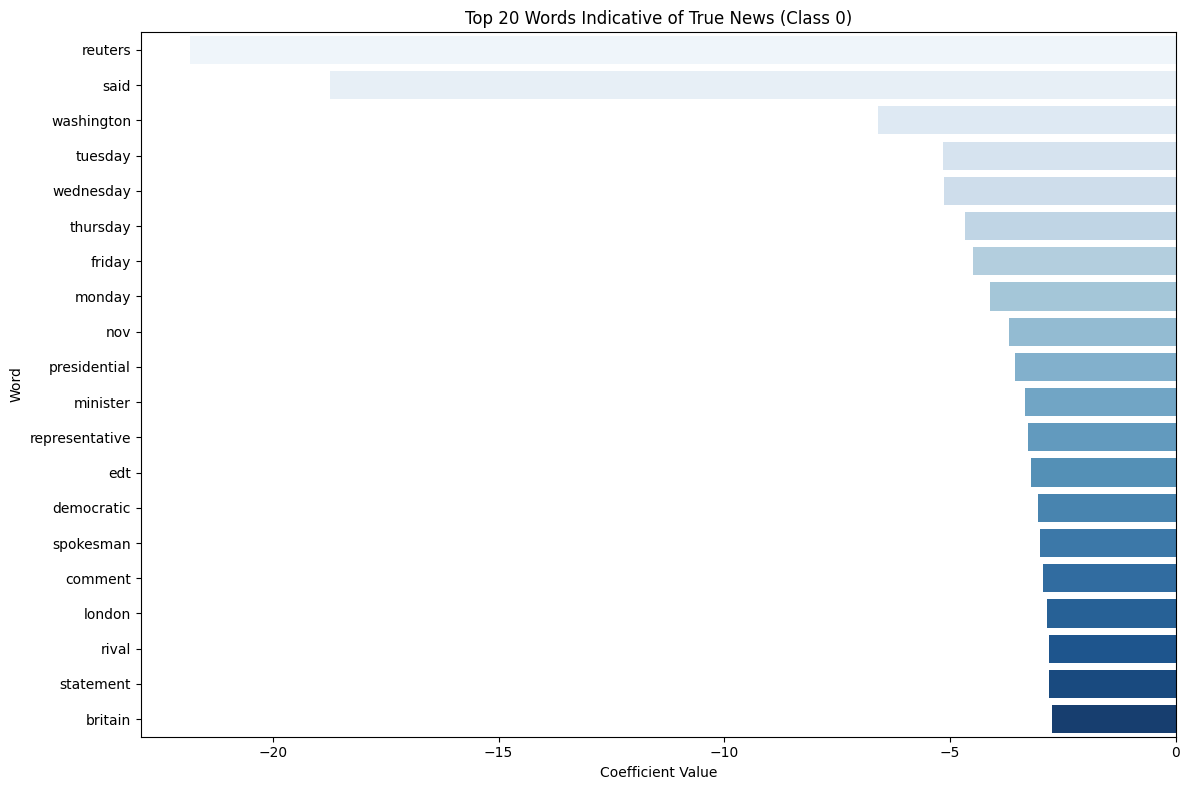

In [ ]:
# Plotting top 20 words for 'Fake' news
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_sorted.head(20), palette='Reds_r')
plt.title('Top 20 Words Indicative of Fake News (Class 1)')
plt.xlabel('Coefficient Value')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# Plotting top 20 words for 'True' news
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_sorted.tail(20).sort_values(by='Coefficient', ascending=True), palette='Blues')
plt.title('Top 20 Words Indicative of True News (Class 0)')
plt.xlabel('Coefficient Value')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# ARTICLE-LEVEL EXPLAINABILITY



In [ ]:

feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

def get_word_contributions(text):

    # Preprocess input text
    processed_tokens = preprocess_text(text)
    cleaned_text = ' '.join(processed_tokens)

    # Convert text to TF-IDF
    text_tfidf = tfidf.transform([cleaned_text])

    # Get non-zero features present in the article
    feature_indices = text_tfidf.nonzero()[1]

    contributions = []

    for index in feature_indices:

        word = feature_names[index]

        # TF-IDF value for this word
        tfidf_value = text_tfidf[0, index]

        # Logistic Regression coefficient
        coefficient = coefficients[index]

        # Contribution toward Fake/Real
        contribution = tfidf_value * coefficient

        contributions.append({
            'Word': word,
            'TF-IDF': tfidf_value,
            'Coefficient': coefficient,
            'Contribution': contribution
        })

    contribution_df = pd.DataFrame(contributions)

    return contribution_df

# Testing

In [ ]:
sample_text = """
The government announced a new policy today that will significantly
change the country's economic system and create thousands of jobs.
"""

contribution_df = get_word_contributions(sample_text)

display(
    contribution_df.sort_values(
        'Contribution',
        ascending=False
    ).head(10)
)

,Word,TF-IDF,Coefficient,Contribution
12,today,0.271758,2.273667,0.617886
0,announced,0.293710,1.242774,0.365016
6,job,0.251854,0.531218,0.133789
9,significantly,0.468581,0.049721,0.023298
3,create,0.340381,0.058180,0.019803
10,system,0.276031,-0.210497,-0.058104
8,policy,0.226262,-0.350462,-0.079296
11,thousand,0.292746,-0.388559,-0.113749
1,change,0.246111,-0.508482,-0.125143
4,economic,0.279844,-0.647401,-0.181172


In [ ]:
def explain_prediction(text, top_n=10):

    contribution_df = get_word_contributions(text)

    # Words pushing prediction toward Fake
    fake_words = contribution_df[
        contribution_df['Contribution'] > 0
    ].sort_values(
        'Contribution',
        ascending=False
    ).head(top_n)

    # Words pushing prediction toward Real
    real_words = contribution_df[
        contribution_df['Contribution'] < 0
    ].sort_values(
        'Contribution',
        ascending=True
    ).head(top_n)

    return fake_words, real_words

In [ ]:
fake_words, real_words = explain_prediction(sample_text)

print("Words contributing toward FAKE:")
display(fake_words)

print("Words contributing toward REAL:")
display(real_words)

Words contributing toward FAKE:


,Word,TF-IDF,Coefficient,Contribution
12,today,0.271758,2.273667,0.617886
0,announced,0.293710,1.242774,0.365016
6,job,0.251854,0.531218,0.133789
9,significantly,0.468581,0.049721,0.023298
3,create,0.340381,0.058180,0.019803


Words contributing toward REAL:


,Word,TF-IDF,Coefficient,Contribution
5,government,0.178712,-2.247789,-0.401707
7,new,0.163135,-1.241496,-0.202532
2,country,0.174647,-1.096966,-0.191582
4,economic,0.279844,-0.647401,-0.181172
1,change,0.246111,-0.508482,-0.125143
11,thousand,0.292746,-0.388559,-0.113749
8,policy,0.226262,-0.350462,-0.079296
10,system,0.276031,-0.210497,-0.058104


# Final Prediction Function

In [ ]:
def predict_news(text):
  # Preprocess input
  processed_tokens = preprocess_text(text)
  cleaned_text = ' '.join(processed_tokens)

  # TF-IDF transformation
  text_tfidf = tfidf.transform([cleaned_text])

  # Prediction
  prediction = log_reg.predict(text_tfidf)[0]

  # Probability
  probabilities = log_reg.predict_proba(text_tfidf)[0]

  # Class probabilities
  real_probability = probabilities[0]
  fake_probability = probabilities[1]

  # Confidence = probability of predicted class
  confidence = probabilities[prediction]

  # Label
  if prediction == 1:
      label = "FAKE"
  else:
      label = "REAL"

  return {
      'prediction': prediction,
      'label': label,
      'confidence': confidence,
      'real_probability': real_probability,
      'fake_probability': fake_probability
  }

In [ ]:
# test
result = predict_news(sample_text)

print("Prediction:", result['label'])
print("Confidence:", result['confidence'])
print("Real Probability:", result['real_probability'])
print("Fake Probability:", result['fake_probability'])

Prediction: FAKE
Confidence: 0.669647682687035
Real Probability: 0.330352317312965
Fake Probability: 0.669647682687035


In [ ]:
# complete test

sample_article = """
The government announced a new economic policy that will create
thousands of jobs across the country. Officials said the policy
will focus on improving employment opportunities and supporting
small businesses.
"""

# Prediction
result = predict_news(sample_article)

print("=" * 50)
print("FAKE NEWS CLASSIFIER")
print("=" * 50)

print(f"\nPrediction       : {result['label']}")
print(f"Confidence       : {result['confidence']:.2%}")
print(f"Real Probability : {result['real_probability']:.2%}")
print(f"Fake Probability : {result['fake_probability']:.2%}")

# Explanation
fake_words, real_words = explain_prediction(sample_article)

print("\nWords pushing toward FAKE:")
display(fake_words[['Word', 'Contribution']])

print("\nWords pushing toward REAL:")
display(real_words[['Word', 'Contribution']])

FAKE NEWS CLASSIFIER

Prediction       : REAL
Confidence       : 79.87%
Real Probability : 79.87%
Fake Probability : 20.13%

Words pushing toward FAKE:


,Word,Contribution
1,announced,0.273870
10,job,0.100382
17,supporting,0.099621
2,business,0.037533
13,opportunity,0.017970
4,create,0.014858



Words pushing toward REAL:


,Word,Contribution
15,said,-1.454080
8,government,-0.301400
12,official,-0.157807
11,new,-0.151959
3,country,-0.143743
5,economic,-0.135933
14,policy,-0.118991
16,small,-0.113183
18,thousand,-0.085346
6,employment,-0.067603


# Saving

In [ ]:
import joblib
import os

# Create deployment folder
os.makedirs('/content/fake_news_model', exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    '/content/fake_news_model/tfidf_vectorizer.pkl'
)

# Save Logistic Regression model
joblib.dump(
    log_reg,
    '/content/fake_news_model/logistic_regression_model.pkl'
)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [ ]:
# saving model metadata

model_info = {
    'model_name': 'Logistic Regression',
    'vectorizer': 'TF-IDF',
    'max_features': 7000,
    'classes': {
        0: 'REAL',
        1: 'FAKE'
    },
    'random_state': 42,
    'test_size': 0.2,
    'accuracy': accuracy_score(y_test, y_pred_log_reg),
    'precision': precision_score(y_test, y_pred_log_reg),
    'recall': recall_score(y_test, y_pred_log_reg),
    'f1_score': f1_score(y_test, y_pred_log_reg)
}

joblib.dump(
    model_info,
    '/content/fake_news_model/model_info.pkl'
)

print(model_info)

{'model_name': 'Logistic Regression', 'vectorizer': 'TF-IDF', 'max_features': 7000, 'classes': {0: 'REAL', 1: 'FAKE'}, 'random_state': 42, 'test_size': 0.2, 'accuracy': 0.9849124152921621, 'precision': 0.988933030646992, 'recall': 0.9778338945005611, 'f1_score': 0.983352144469526}


In [ ]:
# download

from google.colab import files

files.download(
    '/content/fake_news_model/logistic_regression_model.pkl'
)

files.download(
    '/content/fake_news_model/tfidf_vectorizer.pkl'
)

files.download(
    '/content/fake_news_model/model_info.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>